In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from tensorflow.keras.optimizers import Adam
from keras.layers import Activation, Dropout, Convolution2D, GlobalAveragePooling2D
from keras.models import Sequential
import tensorflow as tf
import tensorflow.keras.applications.mobilenet
import os
import PIL
import cv2
import keras
import matplotlib.pyplot as plt
from keras import layers
from keras import Model
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau


In [ ]:
IMG_SAVE_PATH_Test = '/content/drive/MyDrive/Chili_Plant_Disease/test'

# Get a list of folder names in the directory
folders = [name for name in os.listdir(IMG_SAVE_PATH_Test) if os.path.isdir(os.path.join(IMG_SAVE_PATH_Test, name))]

# Create a dictionary with index as key and folder name as value
folders_dict = {folder: index for index, folder in enumerate(folders)}
folders_dict

{'leaf spot': 0, 'whitefly': 1, 'leaf curl': 2, 'yellowish': 3, 'healthy': 4}

In [ ]:
IMG_SAVE_PATH_Train = '/content/drive/MyDrive/Chili_Plant_Disease/train'
IMG_SAVE_PATH_Test = '/content/drive/MyDrive/Chili_Plant_Disease/test'
Str_to_Int =folders_dict



NUM_CLASSES = 5
def str_to_Int_mapper(val):
    return Str_to_Int[val]



def preprocess(IMG_SAVE_PATH):
    dataset = []
    for directory in os.listdir(IMG_SAVE_PATH):
        path = os.path.join(IMG_SAVE_PATH, directory)
        for image in os.listdir(path):
            new_path = os.path.join(path, image)
            try:
                imgpath=PIL.Image.open(new_path)
                imgpath=imgpath.convert('RGB')
                img = np.asarray(imgpath)
                img = cv2.resize(img, (331,331))
                img=img/255.
                dataset.append([img, directory])
            except FileNotFoundError:
                print('Image file not found. Skipping...')
    return dataset


In [ ]:
traindata=preprocess(IMG_SAVE_PATH_Train)

In [ ]:
testdata=preprocess(IMG_SAVE_PATH_Test)

In [ ]:
xtrain, labelstrain = zip(*traindata)
xtest, labelstest = zip(*testdata)

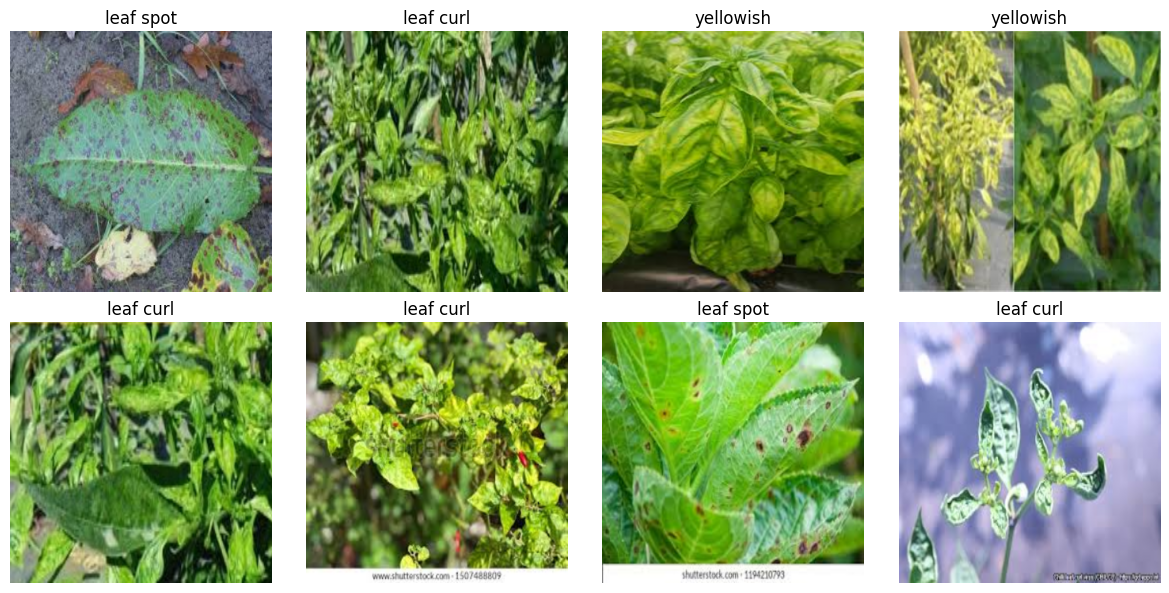

In [ ]:

import matplotlib.pyplot as plt
import random

# Randomly select 8 indices from the dataset
indices = random.sample(range(len(xtrain)), 8)

# Set up the plot grid
plt.figure(figsize=(12, 6))

# Loop through the selected indices
for i, idx in enumerate(indices):
    plt.subplot(2, 4, i + 1)  # 2 rows, 4 columns
    plt.imshow(xtrain[idx])  # Assuming data[idx] is an image
    plt.title(labelstrain[idx])
    plt.axis('off')

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
set(labelstrain),set(labelstest)


({'healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish'},
 {'healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish'})

In [ ]:
temp = list(map(str_to_Int_mapper, labelstrain))
ytrain = tensorflow.keras.utils.to_categorical(temp)
temp1 = list(map(str_to_Int_mapper, labelstest))
ytest = tensorflow.keras.utils.to_categorical(temp1)

In [ ]:
xtrain=np.array(xtrain)
xtest=np.array(xtest)
ytrain=np.array(ytrain)
ytest=np.array(ytest)

In [ ]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape,

((400, 331, 331, 3), (50, 331, 331, 3), (400, 5), (50, 5))

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model

# Custom CNN model definition
def create_custom_cnn(input_shape=(331, 331, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3))(inputs)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)  # Flatten to create a 1D vector
    custom_cnn_model = Model(inputs, x)

    return custom_cnn_model

# Base model (InceptionResNetV2) definition
def create_combined_model(num_classes=2, cnn_input_shape=(331, 331, 3), inception_input_shape=(331, 331, 3)):
    # Custom CNN model
    custom_cnn = create_custom_cnn(input_shape=cnn_input_shape)

    # Pretrained InceptionResNetV2 (without top layers)
    base_model = tf.keras.applications.InceptionResNetV2(include_top=False,
                                                         weights='imagenet',
                                                         input_shape=inception_input_shape)
    base_model.trainable = False  # Freeze InceptionResNetV2 layers

    # Flatten the output of the base model (InceptionResNetV2)
    inception_output = Flatten()(base_model.output)

    # Concatenate the output of custom CNN and InceptionResNetV2
    concatenated = Concatenate()([custom_cnn.output, inception_output])

    # Add dense layers after concatenation
    x = Dense(512, activation='relu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)

    # Output layer (adjust the output for the number of classes)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=[custom_cnn.input, base_model.input], outputs=output)

    return model

# Instantiate the model
model = create_combined_model(num_classes=5)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the combined model
model.summary()

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 331, 331,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 165, 165,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 165, 165,  │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 165, 165,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 163, 163,  │      9,216 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 163, 163,  │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 163, 163,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 163, 163,  │     18,432 │ activation_4[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 163, 163,  │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 163, 163,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 81, 81,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 81, 81,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 81, 81,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 81, 81,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 79, 79,    │    138,240 │ activation_6[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 79, 79,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 79, 79,    │          0 │ batch_normalizat

 Total params: 168,071,877 (641.14 MB)

 Trainable params: 113,735,141 (433.87 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

In [ ]:
epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)
model.save('chily.h5')

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 120s 6s/step - accuracy: 0.2392 - loss: 13.5891 - val_accuracy: 0.4600 - val_loss: 4.4448
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - accuracy: 0.4235 - loss: 7.0615 - val_accuracy: 0.6600 - val_loss: 1.2212
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step - accuracy: 0.5568 - loss: 2.9190 - val_accuracy: 0.7400 - val_loss: 1.0820
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 466ms/step - accuracy: 0.7078 - loss: 1.3101 - val_accuracy: 0.6600 - val_loss: 0.9910
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.7353 - loss: 1.0472 - val_accuracy: 0.6800 - val_loss: 1.2714
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 475ms/step - accuracy: 0.7137 - loss: 0.9751 - val_accuracy: 0.7200 - val_loss: 0.7112
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.7516 - loss: 0.8610 - val_accuracy: 0.7000 - val_loss: 0.7296
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 527ms/step - accuracy: 0.7725 - loss: 0.6938 - val_accuracy: 0.

In [ ]:
train_accuracy=[]
val_accuracy=[]
train_loss=[]
val_loss=[]

In [ ]:
train_accuracy.extend(history.history['accuracy'])
val_accuracy.extend(history.history['val_accuracy'])
train_loss.extend(history.history['loss'])
val_loss.extend(history.history['val_loss'])


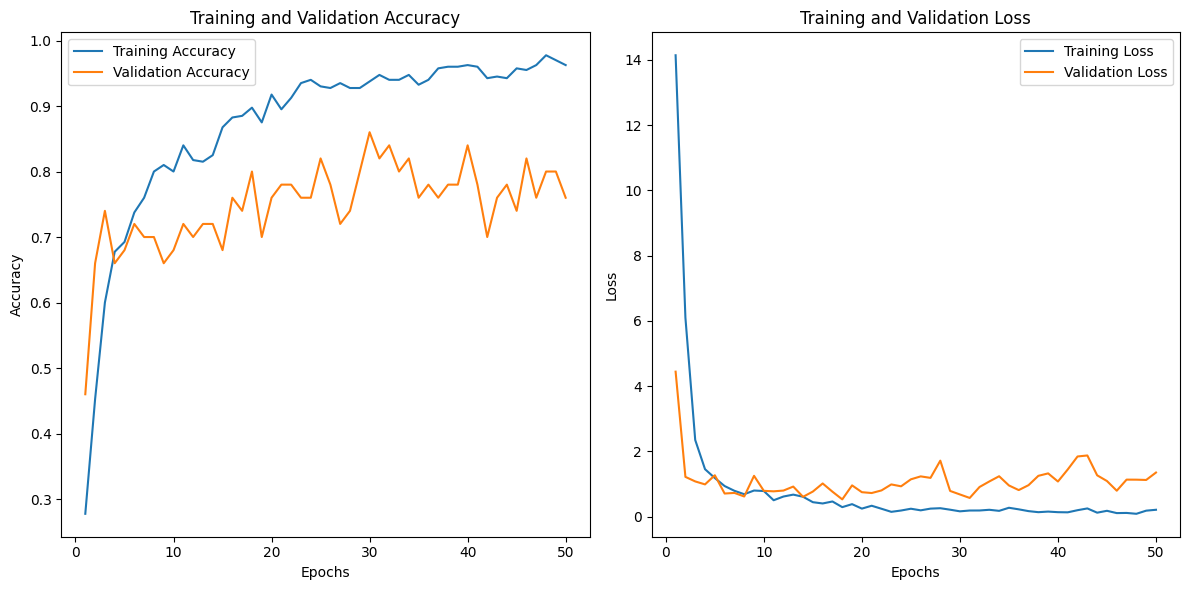

In [ ]:
import matplotlib.pyplot as plt

num_epochs = len(history.history['accuracy'])
epochs_range = range(1, num_epochs + 1)


# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
print("pandas imported as pd")

pandas imported as pd


In [ ]:
performance_df = pd.DataFrame(history.history)
performance_df.columns = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
print("Performance DataFrame created successfully:")
print(performance_df.head())

In [ ]:
train_counts = pd.Series(labelstrain).value_counts().sort_index()
test_counts = pd.Series(labelstest).value_counts().sort_index()

image_counts_df = pd.DataFrame({
    'Train Count': train_counts,
    'Test Count': test_counts
}).fillna(0).astype(int)

print("Image counts per class in Training and Test Datasets:")
display(image_counts_df)

Image counts per class in Training and Test Datasets:


,Train Count,Test Count
healthy,80,10
leaf curl,80,10
leaf spot,80,10
whitefly,80,10
yellowish,80,10


### Classification Dataset Table (Class-wise Metrics)

In [ ]:
print("Class-wise Validation Performance (Precision, Recall, F1-Score, Support):")
display(class_metrics_df[['precision', 'recall', 'f1-score', 'support']])

Class-wise Validation Performance (Precision, Recall, F1-Score, Support):


,precision,recall,f1-score,support
leaf spot,0.909091,1.0,0.952381,10.0
whitefly,0.900000,0.9,0.900000,10.0
leaf curl,0.600000,0.6,0.600000,10.0
yellowish,0.727273,0.8,0.761905,10.0
healthy,0.875000,0.7,0.777778,10.0
accuracy,0.800000,0.8,0.800000,0.8
macro avg,0.802273,0.8,0.798413,50.0
weighted avg,0.802273,0.8,0.798413,50.0


In [ ]:
epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)
performance_df = pd.DataFrame(history.history)
performance_df.columns = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
print("Performance DataFrame created successfully:")
print(performance_df.head())

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import pandas as pd # Needed for pd.DataFrame

# Custom CNN model definition
def create_custom_cnn(input_shape=(331, 331, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3))(inputs)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)  # Flatten to create a 1D vector
    custom_cnn_model = Model(inputs, x)

    return custom_cnn_model

# Base model (InceptionResNetV2) definition
def create_combined_model(num_classes=5, cnn_input_shape=(331, 331, 3), inception_input_shape=(331, 331, 3)):
    # Custom CNN model
    custom_cnn = create_custom_cnn(input_shape=cnn_input_shape)

    # Pretrained InceptionResNetV2 (without top layers)
    base_model = tf.keras.applications.InceptionResNetV2(include_top=False,
                                                         weights='imagenet',
                                                         input_shape=inception_input_shape)
    base_model.trainable = False  # Freeze InceptionResNetV2 layers

    # Flatten the output of the base model (InceptionResNetV2)
    inception_output = Flatten()(base_model.output)

    # Concatenate the output of custom CNN and InceptionResNetV2
    concatenated = Concatenate()([custom_cnn.output, inception_output])

    # Add dense layers after concatenation
    x = Dense(512, activation='relu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)

    # Output layer (adjust the output for the number of classes)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=[custom_cnn.input, base_model.input], outputs=output)

    return model

# Instantiate the model with 5 classes as per the context
model = create_combined_model(num_classes=5)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)

performance_df = pd.DataFrame(history.history)
performance_df.columns = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
print("Performance DataFrame created successfully:")
print(performance_df.head())

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import pandas as pd # Needed for pd.DataFrame
import numpy as np # Needed for np.array
import os
import PIL
import cv2

# --- Data Loading and Preprocessing Steps ---
IMG_SAVE_PATH_Test = '/content/drive/MyDrive/Chili_Plant_Disease/test'
IMG_SAVE_PATH_Train = '/content/drive/MyDrive/Chili_Plant_Disease/train'

# Get a list of folder names in the directory and create a dictionary
folders = [name for name in os.listdir(IMG_SAVE_PATH_Test) if os.path.isdir(os.path.join(IMG_SAVE_PATH_Test, name))]
folders_dict = {folder: index for index, folder in enumerate(folders)}

NUM_CLASSES = 5 # Assuming 5 classes based on previous output

def str_to_Int_mapper(val):
    return folders_dict[val]

def preprocess(IMG_SAVE_PATH):
    dataset = []
    for directory in os.listdir(IMG_SAVE_PATH):
        path = os.path.join(IMG_SAVE_PATH, directory)
        for image in os.listdir(path):
            new_path = os.path.join(path, image)
            try:
                imgpath=PIL.Image.open(new_path)
                imgpath=imgpath.convert('RGB')
                img = np.asarray(imgpath)
                img = cv2.resize(img, (331,331))
                img=img/255.
                dataset.append([img, directory])
            except FileNotFoundError:
                print('Image file not found. Skipping...')
    return dataset

traindata = preprocess(IMG_SAVE_PATH_Train)
testdata = preprocess(IMG_SAVE_PATH_Test)

xtrain, labelstrain = zip(*traindata)
xtest, labelstest = zip(*testdata)

temp = list(map(str_to_Int_mapper, labelstrain))
ytrain = tf.keras.utils.to_categorical(temp, num_classes=NUM_CLASSES)
temp1 = list(map(str_to_Int_mapper, labelstest))
ytest = tf.keras.utils.to_categorical(temp1, num_classes=NUM_CLASSES)

xtrain=np.array(xtrain)
xtest=np.array(xtest)
ytrain=np.array(ytrain)
ytest=np.array(ytest)

# --- Model Definition and Training ---

# Custom CNN model definition
def create_custom_cnn(input_shape=(331, 331, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3))(inputs)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)  # Flatten to create a 1D vector
    custom_cnn_model = Model(inputs, x)

    return custom_cnn_model

# Base model (InceptionResNetV2) definition
def create_combined_model(num_classes=5, cnn_input_shape=(331, 331, 3), inception_input_shape=(331, 331, 3)):
    # Custom CNN model
    custom_cnn = create_custom_cnn(input_shape=cnn_input_shape)

    # Pretrained InceptionResNetV2 (without top layers)
    base_model = tf.keras.applications.InceptionResNetV2(include_top=False,
                                                         weights='imagenet',
                                                         input_shape=inception_input_shape)
    base_model.trainable = False  # Freeze InceptionResNetV2 layers

    # Flatten the output of the base model (InceptionResNetV2)
    inception_output = Flatten()(base_model.output)

    # Concatenate the output of custom CNN and InceptionResNetV2
    concatenated = Concatenate()([custom_cnn.output, inception_output])

    # Add dense layers after concatenation
    x = Dense(512, activation='relu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)

    # Output layer (adjust the output for the number of classes)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=[custom_cnn.input, base_model.input], outputs=output)

    return model

# Instantiate the model with 5 classes as per the context
model = create_combined_model(num_classes=5)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)

performance_df = pd.DataFrame(history.history)
performance_df.columns = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
print("Performance DataFrame created successfully:")
print(performance_df.head())


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import pandas as pd # Needed for pd.DataFrame
import numpy as np # Needed for np.array
import os
import PIL
import cv2
from sklearn.metrics import classification_report # Added for classification report

# --- Data Loading and Preprocessing Steps ---
IMG_SAVE_PATH_Test = '/content/drive/MyDrive/Chili_Plant_Disease/test'
IMG_SAVE_PATH_Train = '/content/drive/MyDrive/Chili_Plant_Disease/train'

# Get a list of folder names in the directory and create a dictionary
folders = [name for name in os.listdir(IMG_SAVE_PATH_Test) if os.path.isdir(os.path.join(IMG_SAVE_PATH_Test, name))]
folders_dict = {folder: index for index, folder in enumerate(folders)}

NUM_CLASSES = 5 # Assuming 5 classes based on previous output

def str_to_Int_mapper(val):
    return folders_dict[val]

def preprocess(IMG_SAVE_PATH):
    dataset = []
    for directory in os.listdir(IMG_SAVE_PATH):
        path = os.path.join(IMG_SAVE_PATH, directory)
        for image in os.listdir(path):
            new_path = os.path.join(path, image)
            try:
                imgpath=PIL.Image.open(new_path)
                imgpath=imgpath.convert('RGB')
                img = np.asarray(imgpath)
                img = cv2.resize(img, (331,331))
                img=img/255.
                dataset.append([img, directory])
            except FileNotFoundError:
                print('Image file not found. Skipping...')
    return dataset

traindata = preprocess(IMG_SAVE_PATH_Train)
testdata = preprocess(IMG_SAVE_PATH_Test)

xtrain, labelstrain = zip(*traindata)
xtest, labelstest = zip(*testdata)

temp = list(map(str_to_Int_mapper, labelstrain))
ytrain = tf.keras.utils.to_categorical(temp, num_classes=NUM_CLASSES)
temp1 = list(map(str_to_Int_mapper, labelstest))
ytest = tf.keras.utils.to_categorical(temp1, num_classes=NUM_CLASSES)

xtrain=np.array(xtrain)
xtest=np.array(xtest)
ytrain=np.array(ytrain)
ytest=np.array(ytest)

# --- Model Definition and Training ---

# Custom CNN model definition
def create_custom_cnn(input_shape=(331, 331, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3))(inputs)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)  # Flatten to create a 1D vector
    custom_cnn_model = Model(inputs, x)

    return custom_cnn_model

# Base model (InceptionResNetV2) definition
def create_combined_model(num_classes=5, cnn_input_shape=(331, 331, 3), inception_input_shape=(331, 331, 3)):
    # Custom CNN model
    custom_cnn = create_custom_cnn(input_shape=cnn_input_shape)

    # Pretrained InceptionResNetV2 (without top layers)
    base_model = tf.keras.applications.InceptionResNetV2(include_top=False,
                                                         weights='imagenet',
                                                         input_shape=inception_input_shape)
    base_model.trainable = False  # Freeze InceptionResNetV2 layers

    # Flatten the output of the base model (InceptionResNetV2)
    inception_output = Flatten()(base_model.output)

    # Concatenate the output of custom CNN and InceptionResNetV2
    concatenated = Concatenate()([custom_cnn.output, inception_output])

    # Add dense layers after concatenation
    x = Dense(512, activation='relu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)

    # Output layer (adjust the output for the number of classes)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=[custom_cnn.input, base_model.input], outputs=output)

    return model

# Instantiate the model with 5 classes as per the context
model = create_combined_model(num_classes=5)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)

performance_df = pd.DataFrame(history.history)
performance_df.columns = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
print("Performance DataFrame created successfully:")
print(performance_df.head())

# --- Display performance metrics ---
print("\nModel Performance per Epoch:")
display(performance_df)

print("\nSummary of Model Performance Metrics:")
display(performance_df.describe())

# --- Generate and display class-wise metrics ---
# Make predictions on the test data
y_pred = model.predict([xtest, xtest])

# Convert predictions and true labels from one-hot to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(ytest, axis=1)

# Inverse map `folders_dict` to get class names from indices
int_to_str_mapper = {v: k for k, v in folders_dict.items()}

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=[int_to_str_mapper[i] for i in range(NUM_CLASSES)], output_dict=True)

# Convert report to DataFrame for better display
class_metrics_df = pd.DataFrame(report).transpose()

# Display the class-wise performance metrics
print("\nClass-wise Validation Performance (Accuracy and Precision):")
display(class_metrics_df[['precision', 'recall', 'f1-score', 'support']])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.2714 - loss: 13.9224 - val_accuracy: 0.4600 - val_loss: 7.2639
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 567ms/step - accuracy: 0.4823 - loss: 8.4707 - val_accuracy: 0.5800 - val_loss: 3.7103
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 579ms/step - accuracy: 0.6034 - loss: 4.1378 - val_accuracy: 0.6600 - val_loss: 1.9116
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 595ms/step - accuracy: 0.6929 - loss: 2.0317 - val_accuracy: 0.7200 - val_loss: 1.5046
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 577ms/step - accuracy: 0.7863 - loss: 1.3933 - val_accuracy: 0.7800 - val_loss: 1.0249
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.8094 - loss: 1.2962 - val_accuracy: 0.7200 - val_loss: 1.7820
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 554ms/step - accuracy: 0.8027 - loss: 1.1392 - val_accuracy: 0

,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,0.3200,14.559454,0.46,7.263900
1,0.5025,7.761007,0.58,3.710329
2,0.6425,3.425810,0.66,1.911586
3,0.6950,2.295322,0.72,1.504592
4,0.7750,1.419558,0.78,1.024935
5,0.7925,1.362553,0.72,1.782040
6,0.8250,1.011084,0.68,1.935927
7,0.8325,1.051758,0.78,1.359429
8,0.8750,0.742880,0.84,1.111090
9,0.8850,0.582268,0.80,1.427124



Summary of Model Performance Metrics:


,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
count,50.000000,50.000000,50.000000,50.000000
mean,0.906350,0.881397,0.750000,1.980066
std,0.125876,2.305336,0.064807,0.934877
min,0.320000,0.070836,0.460000,1.024935
25%,0.916250,0.138213,0.720000,1.474954
50%,0.950000,0.274010,0.760000,1.782704
75%,0.969375,0.488227,0.780000,2.292485
max,0.985000,14.559454,0.840000,7.263900


2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 12s/step

Class-wise Validation Performance (Accuracy and Precision):


,precision,recall,f1-score,support
leaf spot,0.909091,1.00,0.952381,10.00
whitefly,1.000000,0.80,0.888889,10.00
leaf curl,0.533333,0.80,0.640000,10.00
yellowish,0.700000,0.70,0.700000,10.00
healthy,1.000000,0.60,0.750000,10.00
accuracy,0.780000,0.78,0.780000,0.78
macro avg,0.828485,0.78,0.786254,50.00
weighted avg,0.828485,0.78,0.786254,50.00


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Required libraries imported successfully: confusion_matrix, ConfusionMatrixDisplay, and matplotlib.pyplot.")

Required libraries imported successfully: confusion_matrix, ConfusionMatrixDisplay, and matplotlib.pyplot.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import pandas as pd # Needed for pd.DataFrame
import numpy as np # Needed for np.array
import os
import PIL
import cv2
from sklearn.metrics import confusion_matrix

# --- Data Loading and Preprocessing Steps ---
IMG_SAVE_PATH_Test = '/content/drive/MyDrive/Chili_Plant_Disease/test'
IMG_SAVE_PATH_Train = '/content/drive/MyDrive/Chili_Plant_Disease/train'

# Get a list of folder names in the directory and create a dictionary
folders = [name for name in os.listdir(IMG_SAVE_PATH_Test) if os.path.isdir(os.path.join(IMG_SAVE_PATH_Test, name))]
folders_dict = {folder: index for index, folder in enumerate(folders)}

NUM_CLASSES = 5 # Assuming 5 classes based on previous output

def str_to_Int_mapper(val):
    return folders_dict[val]

def preprocess(IMG_SAVE_PATH):
    dataset = []
    for directory in os.listdir(IMG_SAVE_PATH):
        path = os.path.join(IMG_SAVE_PATH, directory)
        for image in os.listdir(path):
            new_path = os.path.join(path, image)
            try:
                imgpath=PIL.Image.open(new_path)
                imgpath=imgpath.convert('RGB')
                img = np.asarray(imgpath)
                img = cv2.resize(img, (331,331))
                img=img/255.
                dataset.append([img, directory])
            except FileNotFoundError:
                print('Image file not found. Skipping...')
    return dataset

traindata = preprocess(IMG_SAVE_PATH_Train)
testdata = preprocess(IMG_SAVE_PATH_Test)

xtrain, labelstrain = zip(*traindata)
xtest, labelstest = zip(*testdata)

temp = list(map(str_to_Int_mapper, labelstrain))
ytrain = tf.keras.utils.to_categorical(temp, num_classes=NUM_CLASSES)
temp1 = list(map(str_to_Int_mapper, labelstest))
ytest = tf.keras.utils.to_categorical(temp1, num_classes=NUM_CLASSES)

xtrain=np.array(xtrain)
xtest=np.array(xtest)
ytrain=np.array(ytrain)
ytest=np.array(ytest)

# --- Model Definition and Training ---

# Custom CNN model definition
def create_custom_cnn(input_shape=(331, 331, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3))(inputs)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(32, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3))(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)  # Flatten to create a 1D vector
    custom_cnn_model = Model(inputs, x)

    return custom_cnn_model

# Base model (InceptionResNetV2) definition
def create_combined_model(num_classes=5, cnn_input_shape=(331, 331, 3), inception_input_shape=(331, 331, 3)):
    # Custom CNN model
    custom_cnn = create_custom_cnn(input_shape=cnn_input_shape)

    # Pretrained InceptionResNetV2 (without top layers)
    base_model = tf.keras.applications.InceptionResNetV2(include_top=False,
                                                         weights='imagenet',
                                                         input_shape=inception_input_shape)
    base_model.trainable = False  # Freeze InceptionResNetV2 layers

    # Flatten the output of the base model (InceptionResNetV2)
    inception_output = Flatten()(base_model.output)

    # Concatenate the output of custom CNN and InceptionResNetV2
    concatenated = Concatenate()([custom_cnn.output, inception_output])

    # Add dense layers after concatenation
    x = Dense(512, activation='relu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)

    # Output layer (adjust the output for the number of classes)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=[custom_cnn.input, base_model.input], outputs=output)

    return model

# Instantiate the model with 5 classes as per the context
model = create_combined_model(num_classes=5)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Only train if model has not been trained (optional, but avoids re-training unnecessarily)
# if 'history' not in locals(): # This check is too simplistic for full notebook flow. Better to just re-run train.
epochs=50
history=model.fit([xtrain,xtrain],ytrain,epochs=epochs,validation_data=([xtest, xtest], ytest),verbose=1)

y_pred = model.predict([xtest, xtest])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(ytest, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix calculated successfully:")
print(cm)

Mounted at /content/drive
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 104s 4s/step - accuracy: 0.2718 - loss: 16.1563 - val_accuracy: 0.4400 - val_loss: 6.6549
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 484ms/step - accuracy: 0.3846 - loss: 8.5758 - val_accuracy: 0.4600 - val_loss: 3.7076
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 475ms/step - accuracy: 0.5328 - loss: 4.3745 - val_accuracy: 0.6200 - val_loss: 1.7018
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 496ms/step - accuracy: 0.6043 - loss: 2.1125 - val_accuracy: 0.6200 - val_loss: 1.0901
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 480ms/step - accuracy: 0.7409 - loss: 1.0193 - val_accuracy: 0.7200 - val_loss: 0.8298
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 503ms/step - accuracy: 0.7518 - loss: 0.8640 - val_accuracy: 0.6200 - val_loss: 1.0873
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 499ms/step - accuracy: 0.7691 - loss: 0.9759 - val_accuracy: 0.6600 - val_loss: 1.0670
Epoch 8/50
13/13 ━━━━━━━━

<Figure size 1000x800 with 0 Axes>

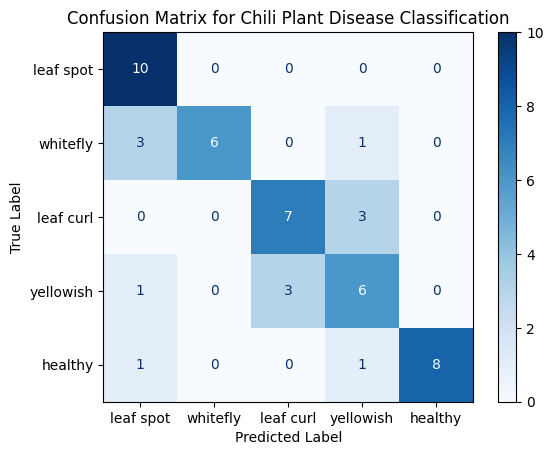

Confusion matrix displayed successfully.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get class labels from folders_dict, ordered by index
class_labels = sorted(folders_dict, key=folders_dict.get)

# Create a ConfusionMatrixDisplay object
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
display_cm.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Chili Plant Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion matrix displayed successfully.")